# xvenue_tick — cross-venue τ gaps / grid pressure / SOR

**Book:** Rindi et al., *Tick Size: Theory and Evidence* (MMCV #3 Paris 2014)  
**Package:** same-coin τ gap HL↔Deribit↔Kraken as primary crypto QE (deck LSE RDD parked).  
**SoT:** [`NOTES.md`](NOTES.md) · [`EXP_REPORT.md`](EXP_REPORT.md) · [`CANDIDATES.md`](CANDIDATES.md)  
**Lib:** `research.lib.ticksize` (+ `epps.corr_vs_lag`, `fei.fei`) — do not paste.  
**Runner:** [`_run_xvenue.py`](_run_xvenue.py) → [`../../out/xvenue_tick/`](../../out/xvenue_tick/)

### Verdict
ETH HL τ≈**0.1** vs Deribit **0.05** (stable 2×) vs Kraken ≈**0.1** (inferred). τ-gap alone does **not** explain MQ Δ (venue confound). All xvenue candidates stay **Hold** except vanity RDD **Kill**. No Promote without fee/latency fill labels + FE.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, Markdown, display

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mm_confr_viewpoints')
OUT = BOOK / 'out' / 'xvenue_tick'
FIGS = OUT / 'figs'
S = json.loads((OUT / 'xvenue_summary.json').read_text())
print('symbols', S['symbols'], 'days', S['days'])
print('n_pairs', len(S['pairs']), 'n_btc_rows', S['n_btc_rows'])
print('figs', S['figs'])

symbols ['BTC', 'ETH'] days ['2026-09-26', '2026-09-27', '2026-09-30']
n_pairs 15 n_btc_rows 6
figs ['out/xvenue_tick/figs/fig_tau_gap_heatmap.png', 'out/xvenue_tick/figs/fig_mq_delta_vs_tau_gap.png', 'out/xvenue_tick/figs/fig_grid_pressure_residuals.png', 'out/xvenue_tick/figs/fig_concord_fei_epps.png', 'out/xvenue_tick/figs/fig_sor_preference.png']


## Sample & data limitations

| Item | Value |
|------|-------|
| Core venues | Hyperliquid, Deribit, Kraken |
| ETH days | pass1 panel (TOB+trades, completeness flagged) |
| BTC | opportunistic 2-day probe (τ **inferred**; Kraken trade-synth TOB) |
| Clocks | exchange timestamps as stored; **no latency haircut** |

**Limitations (do not Promote past these):**

In [2]:
for line in S['limitations']:
    print('•', line)
print('\ncompleteness head:')
for c in S['completeness'][:6]:
    print(c)

• Kraken TOB often trade-synthesized or inferred τ — treat absolute τ as soft.
• Depth units not cross-venue comparable (contracts vs coin); depth_gap is directional only.
• ETH slice = 3 UTC days from pass1 panel; BTC opportunistic if loaders succeed.
• No fee / latency / markout fill label for SOR — preference is MQ-rank heuristic.
• Epps assumes comparable exchange clocks; no latency haircut.
• ClickHouse MCP banned; warehouse + collector TOB only.

completeness head:
{'symbol': 'ETH', 'venue': 'hyperliquid', 'day': '2026-09-26', 'complete': True, 'n': 69357, 'tob_ok': True, 'tau': 0.1, 'tau_source': 'known', 'tob_source': 'warehouse:l2_rebuild/s3_cache'}
{'symbol': 'ETH', 'venue': 'deribit', 'day': '2026-09-26', 'complete': True, 'n': 27440, 'tob_ok': True, 'tau': 0.05, 'tau_source': 'known', 'tob_source': 'warehouse:l2_tob/s3_cache'}
{'symbol': 'ETH', 'venue': 'kraken', 'day': '2026-09-26', 'complete': True, 'n': 40843, 'tob_ok': True, 'tau': 0.09999999999990905, 'tau_source': 'in

## Pass 1 — τ gap heatmap (HL↔Deribit↔Kraken)

Deck mapping: sovereign price→tick RDD **unavailable** on perps → same-coin absolute τ gap is the QE.

- ETH: HL−DB = **+0.05** every day; HL−KR ≈ **0**; DB−KR = **−0.05**.
- BTC: HL−DB ≈ **+0.50** (inferred τ 1.0 vs 0.5); Kraken τ soft (trade-synth).

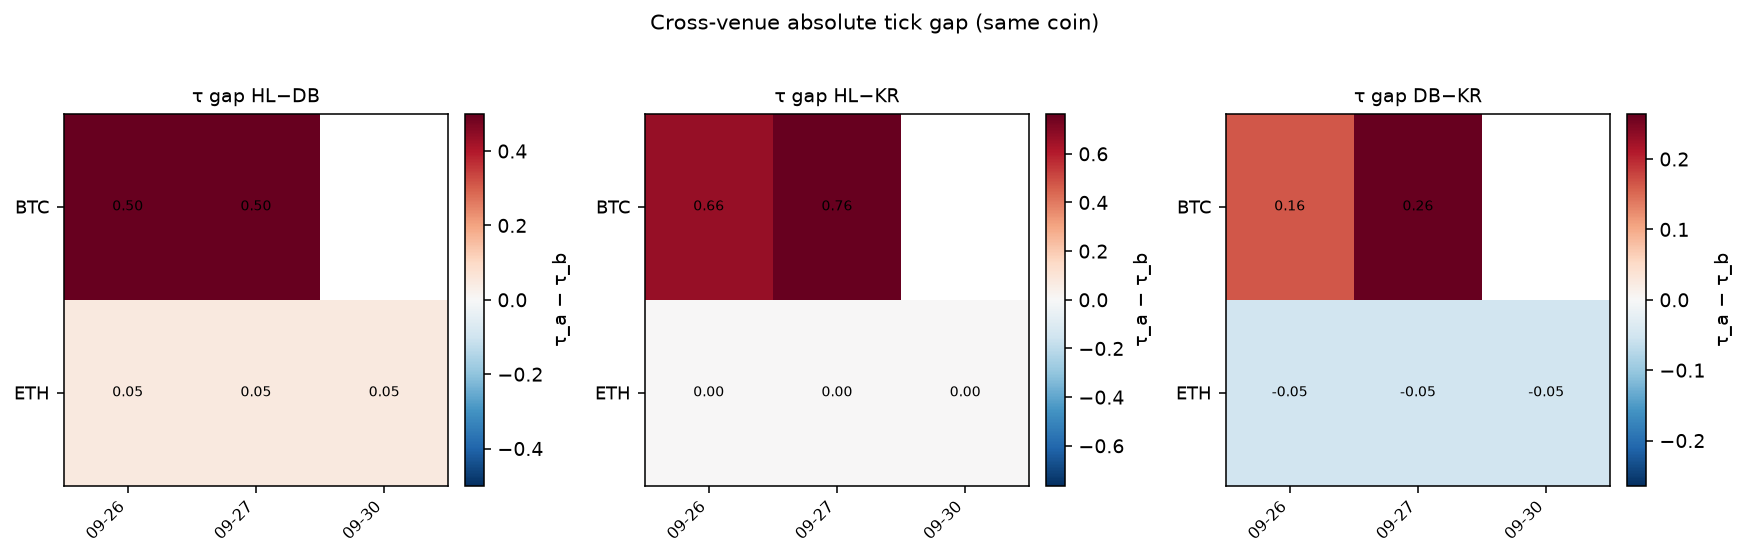

In [3]:
display(Image(filename=str(FIGS / 'fig_tau_gap_heatmap.png')))

## Pass 1 — MQ Δ vs τ gap

If finer ticks improved MQ mechanically, larger positive τ gap (A coarser than B) should widen A's relative spread. Observed Pearson on this slice:

- spread Δ: weak negative (venue confound: HL often tighter despite coarser/equal τ vs Deribit)
- depth Δ: sparse + unit-incomparable across venues → directional only
- volume Δ: weak

MQ scatter stats: {
  "spread_gap_bps": {
    "n": 15,
    "pearson": -0.3419361366599481
  },
  "depth_gap": {
    "n": 5,
    "pearson": -0.9867689665076016
  },
  "volume_gap": {
    "n": 15,
    "pearson": -0.2947701658184274
  }
}


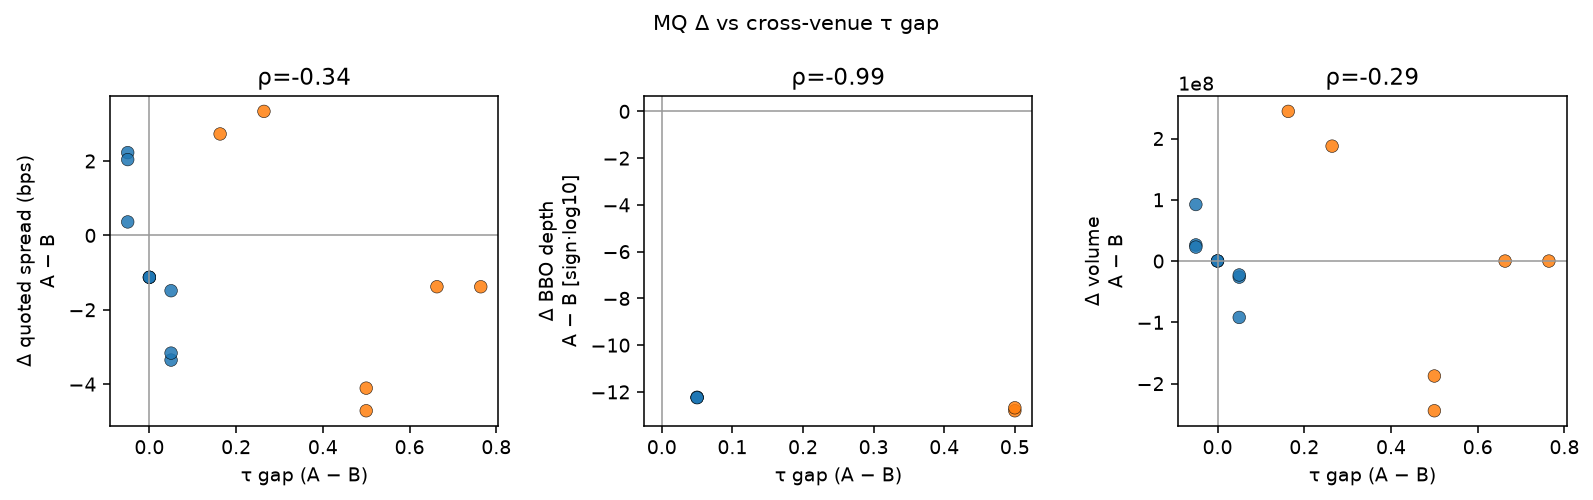

In [4]:
print('MQ scatter stats:', json.dumps(S['mq_scatter'], indent=2))
display(Image(filename=str(FIGS / 'fig_mq_delta_vs_tau_gap.png')))

## Pass 1 — grid-pressure residuals

Within venue, τ fixed → relative tick moves only via mid. Residualize hour spread on hour rel_tick; residual vs Δ(τ/mid) from day-open.

ρ ≈ 0 after linear residualization → pressure channel absorbed by rel_tick (Hold `frag.grid_pressure`; needs FE / nonlinear falsifier).

grid: {'n_points': 258, 'rho_pressure_resid_spread': 1.8295139533052334e-16}


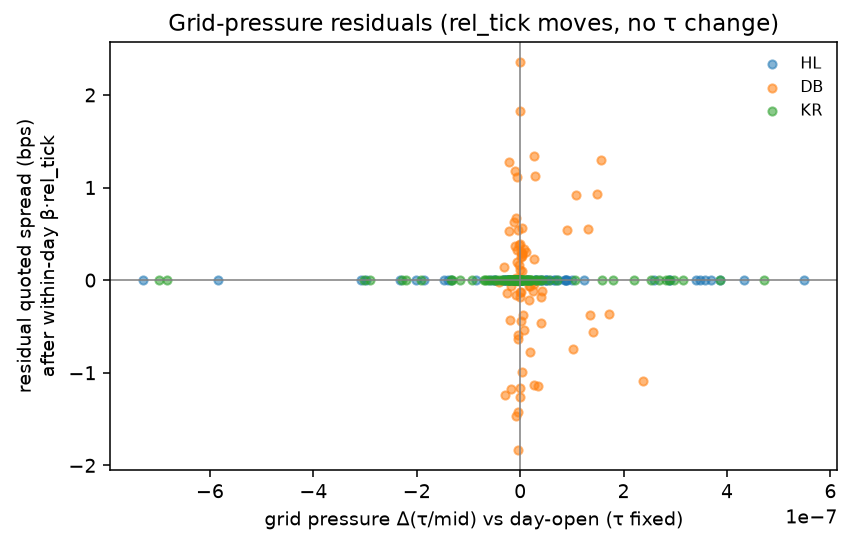

In [5]:
print('grid:', S['grid'])
display(Image(filename=str(FIGS / 'fig_grid_pressure_residuals.png')))

## Pass 2 — concordance / FEI / Epps around high relative-tick

Helpers: `research.lib.fei.fei`, `research.lib.epps.corr_vs_lag`.

- **Concordance:** Jaccard of top-quartile rel_tick UTC hours across venue pairs (mean ~0.73 on slice).
- **FEI:** 3-venue volume shares — very low (volume concentrated), descriptive only.
- **Epps:** ETH 2026-09-26 high-τ/mid hours — classic rising corr vs lag (HL–DB / HL–KR ~0.22@1s → ~0.9@300s).

concord_mean 0.7317460317460317
epps_note ETH 2026-09-26; n_pairs=3
FEI BTC 2026-09-26 0.0005
FEI BTC 2026-09-27 0.0006
FEI ETH 2026-09-26 0.0272
FEI ETH 2026-09-27 0.0396
FEI ETH 2026-09-30 0.0253


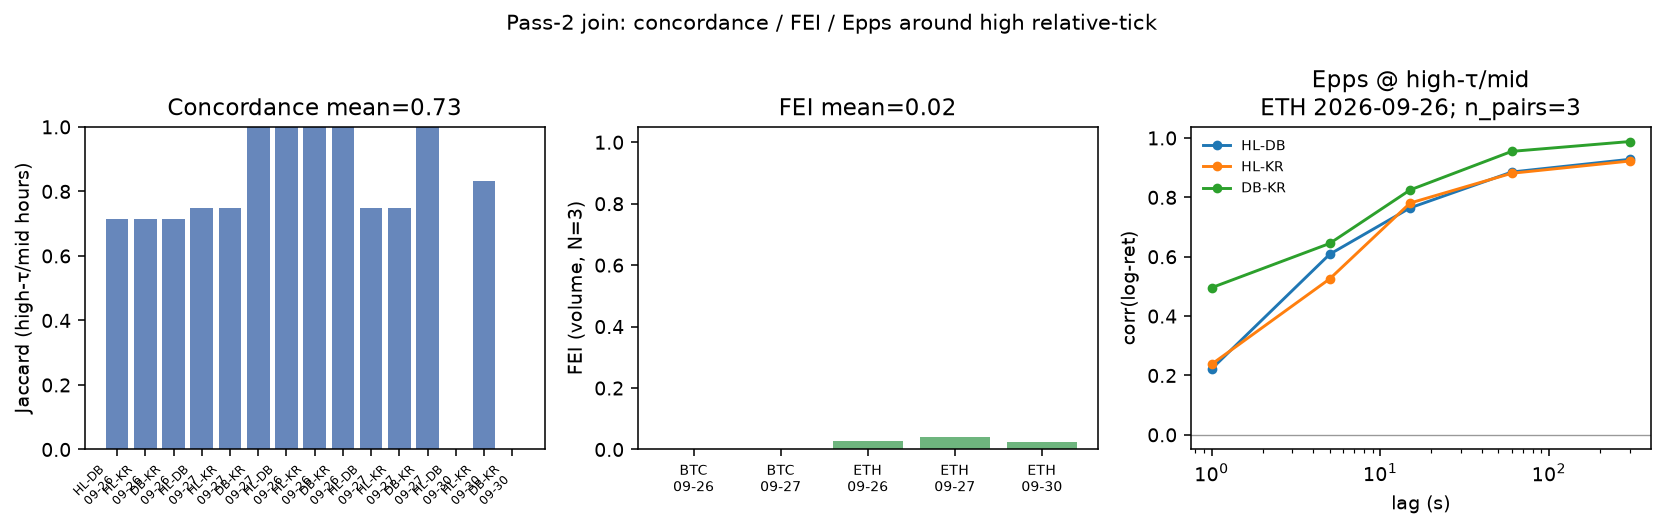

In [6]:
ce = S['concord_epps']
print('concord_mean', ce['concord_mean'])
print('epps_note', ce['epps_note'])
for f in ce['fei']:
    print('FEI', f['symbol'], f['day'], round(f['fei_volume'], 4))
display(Image(filename=str(FIGS / 'fig_concord_fei_epps.png')))

## Pass 2 — SOR implication panel

Heuristic only: prefer venue with lower mean rank of (quoted spread, rel_tick_bps, −depth).

- BTC days: composite leans **Kraken** (soft — synth TOB / inferred τ).
- ETH: **HL** on early days, **Deribit** on 09-30.

**Hold** `exec.sor_rel_tick` until fee + latency + fill-quality labels exist.

prefer_counts {'kraken': 2, 'hyperliquid': 2, 'deribit': 1}


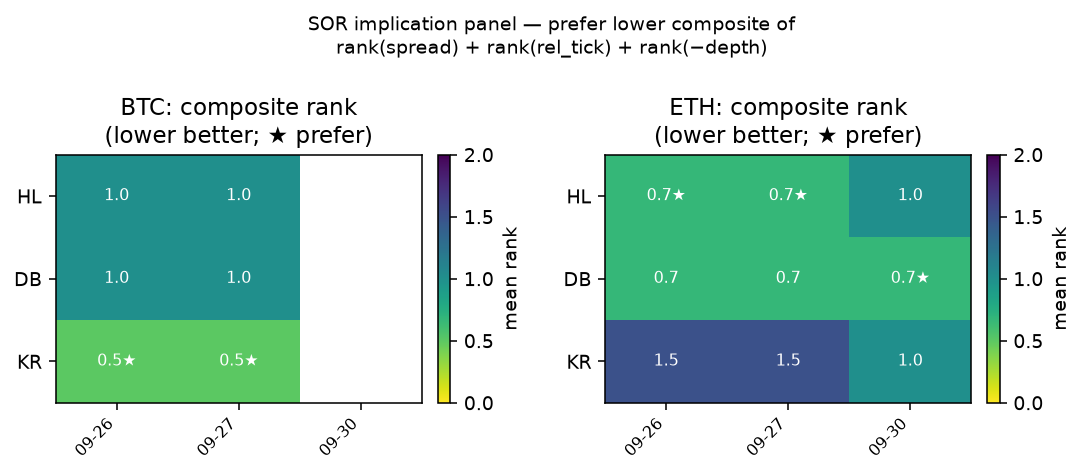

In [7]:
print('prefer_counts', S['sor']['prefer_counts'])
display(Image(filename=str(FIGS / 'fig_sor_preference.png')))

## Signal board (package-local)

| id | desk job | decision |
|----|----------|----------|
| `frag.xvenue_tau_gap` | fragmentation / disc monitor | **Hold** |
| `frag.grid_pressure` | disc / liq feature | **Hold** |
| `frag.xvenue_rel_tick_concord` | sync / info | **Hold** |
| `frag.fei_epps_hightick` | frag / cont diagnostic | **Hold** |
| `exec.sor_rel_tick` | exec throttle heuristic | **Hold** |
| `id.vanity_price_rdd` | identification | **Kill** |

Re-run: `python3 chapters/xvenue_tick/_run_xvenue.py` from book root context (script paths absolute).